In [7]:
import os
from mistralai import Mistral
import os
import json
import random
import time

In [8]:
api_key = "ujI60UR6Fe5jel48SAtfnMiN5Skxfwhq"
#kostenlloses model
model =  "open-mistral-nemo"
client = Mistral(api_key=api_key)

In [9]:
import os
import json
import time

# === File paths ===
input_path = r"C:\Users\cdoering\OneDrive - IW\Dokumente\Capstone\CapstoneDATEV25-1\competency_questions_output\clustered_CQs_with_promoted_and_reviewed_noise.json"
output_file_path = "ontology_output/ontology_from_clustered_cqs.json"
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

# === Load clustered CQs ===
with open(input_path, "r", encoding="utf-8") as f:
    clustered_cqs = json.load(f)

# === Filter: exclude 'Cluster -1' and keep first 10 clusters ===
filtered_clusters = {
    k: v for k, v in sorted(clustered_cqs.items())
    if k != "Cluster -1"
}
selected_clusters = dict(list(filtered_clusters.items())[:10])

# === System Prompt ===
ontology_system_prompt = """
You are an expert legal ontology engineer.

Your task is to extract ontology components from the given legal ruling text (German court decisions). 
Identify and return three structured components:

1. **Classes**: Legal entities or concepts (e.g., Urteil, Entscheidungsgründe, Anspruch, Person, Tatbestand, Eiwendung, Rubrum, Tenor)
2. **Properties**: Verbs or phrases representing relationships or attributes (e.g., beinhaltet, basiert auf, verhindert, erörtern)
3. **Relationships**: Triples (Subject)-(Predicate)-(Object), connecting two classes using a property

Requirements:
- Only extract concepts if they have relationships.
- Use clear legal language in German.
- Output must follow this structure (example):

{
  "classes": ["Urteil", "Anspruch", "Tatbestand"],
  "properties": ["beinhaltet", "basiert auf"],
  "relationships": [
    ["Urteil", "beinhaltet", "Tatbestand"],
    ["Anspruch", "basiert auf", "Tatbestand"]
  ]
}

## Few-Shot Examples 
"Sentence: 'Ein Arbeitnehmer hat eine Sozialversicherungsnummer'"
"Classes: [Arbeitnehmner, Sozialversicherungsnummer]"
"Properties: [hatIdentifikation]"
"Relationship: [(Arbeitnehmer)-(hatIdentifikation)-(Sozialversicherungsnummer)]"

"Sentence: 'Arbeitnehmer haben nach Gesetz einen geregelten Mindestanspruch auf 24 Tage Urlaub im Jahr'"
"Classes: [Arbeitnehmer, Urlaub]"
"Properties: [hatMindestAnspruchAuf]"
"Relationship: [(Arbeitnehmer)-(hatMindestAnspruchAuf)-(Urlaub)]"

## Modelling Guidelines
- **Concept Identification**:
  - Identify nouns and noun phrases as potential **Classes**.
  - Identify verbs and verb phrases as potential **Properties**.
  - Identify prepositions that establish relationships between nouns.

- **Classes**:
  - Represent concepts in the domain, not the words that denote these concepts.
  - Avoid creating classes for synonyms; use a single class for concepts with the same meaning.

- **Properties**:
  - Represent significant relationships or attributes between classes.
  - Should be meaningful and represent a significant connection.

- **Relationships**:
  - Establish connections between classes using properties.
  - Ensure relationships are meaningful within the domain context.

- **General Principles**:
  - There is no single correct way to model a domain; the best solution depends on the application.
  - Ontology development is an iterative process; refine as needed.
  - Avoid cycles in the class hierarchy.
  - Siblings in the hierarchy should be at the same level of generality.

## Naming Conventions
**General**:
- Do not add strings like 'class', 'domain', 'range', 'property', or 'slot' to names.
- Use consistent naming throughout the ontology.

**Classes**:
- Names are always capitalized.
- Use nouns or compound nouns (e.g., Vertrag, Arbeit, Arbeitsvertrag).
- Use singular over plural (e.g., Arbeitsvertrag instead of Arbeitsverträge).
- Avoid abbreviations (e.g., Arbeitgeber instead of AG).

**Properties**:
- Names start with a lower-case letter.
- Use verbs or verb phrases.
- Can contain nouns in CamelCase starting with a verb (e.g., hatAnspruchAuf).
- Do not include spaces, commas, asterisks, or special characters.

## Finally
- Ensure that you include empty lists for classes, properties, or relationships if none are found.
- Make sure all extracted components, i.e. classes, properties, and relationships as well as all descriptions are in German and translate where necessary.
- Include a class only if at least one relationship is found for a class. Verify this requirement.
- Check carefully for each class without any relationship, based on the name and the description of the class, if it can be merged with another class or if it is actually a relationship between one class and another. This is particularly relevant for classes that are named in the form of 'has something'.
- All ontology components must be in German language!
- Terms like 'range' or 'domain' are never allowed!

Only return JSON. Do not explain or comment.
"""

# === Prompt Builder ===
def build_prompt(cq_list):
    questions = "\n".join(f"- {entry['cq']}" for entry in cq_list)
    return f"Extract ontology components from the following set of legal competency questions:\n\n{questions}"

# === Main loop ===
ontology_results = {}

for cluster_id, cq_list in selected_clusters.items():
    prompt = build_prompt(cq_list)
    try:
        response = client.chat.complete(
            model=model,
            messages=[
                {"role": "system", "content": ontology_system_prompt},
                {"role": "user", "content": prompt}
            ],
            temperature=0.5
        )
        content = response.choices[0].message.content.strip()
        try:
            ontology = json.loads(content)

            # ✅ Nur Triplets akzeptieren
            relationships = ontology.get("relationships", [])
            if isinstance(relationships, list) and all(
                isinstance(r, list) and len(r) == 3 for r in relationships
            ):
                ontology_results[cluster_id] = {
                    "competency_questions": [entry["cq"] for entry in cq_list],
                    "ontology": ontology
                }
                print(f"✅ Ontology extracted for {cluster_id}")
            else:
                print(f"❌ Invalid triplets in relationships for {cluster_id}")

        except json.JSONDecodeError:
            print(f"❌ Invalid JSON for {cluster_id}")
    except Exception as e:
        print(f"❌ Error for {cluster_id}: {e}")
    time.sleep(1)

# === Save results ===
with open(output_file_path, "w", encoding="utf-8") as f_out:
    json.dump(ontology_results, f_out, indent=2, ensure_ascii=False)

print("✅ Ontology extraction per cluster completed.")


✅ Ontology extracted for Cluster 0
❌ Invalid triplets in relationships for Cluster 1
✅ Ontology extracted for Cluster 10
❌ Invalid triplets in relationships for Cluster 100
✅ Ontology extracted for Cluster 101
✅ Ontology extracted for Cluster 102
✅ Ontology extracted for Cluster 103
✅ Ontology extracted for Cluster 104
✅ Ontology extracted for Cluster 105
✅ Ontology extracted for Cluster 106
✅ Ontology extraction per cluster completed.


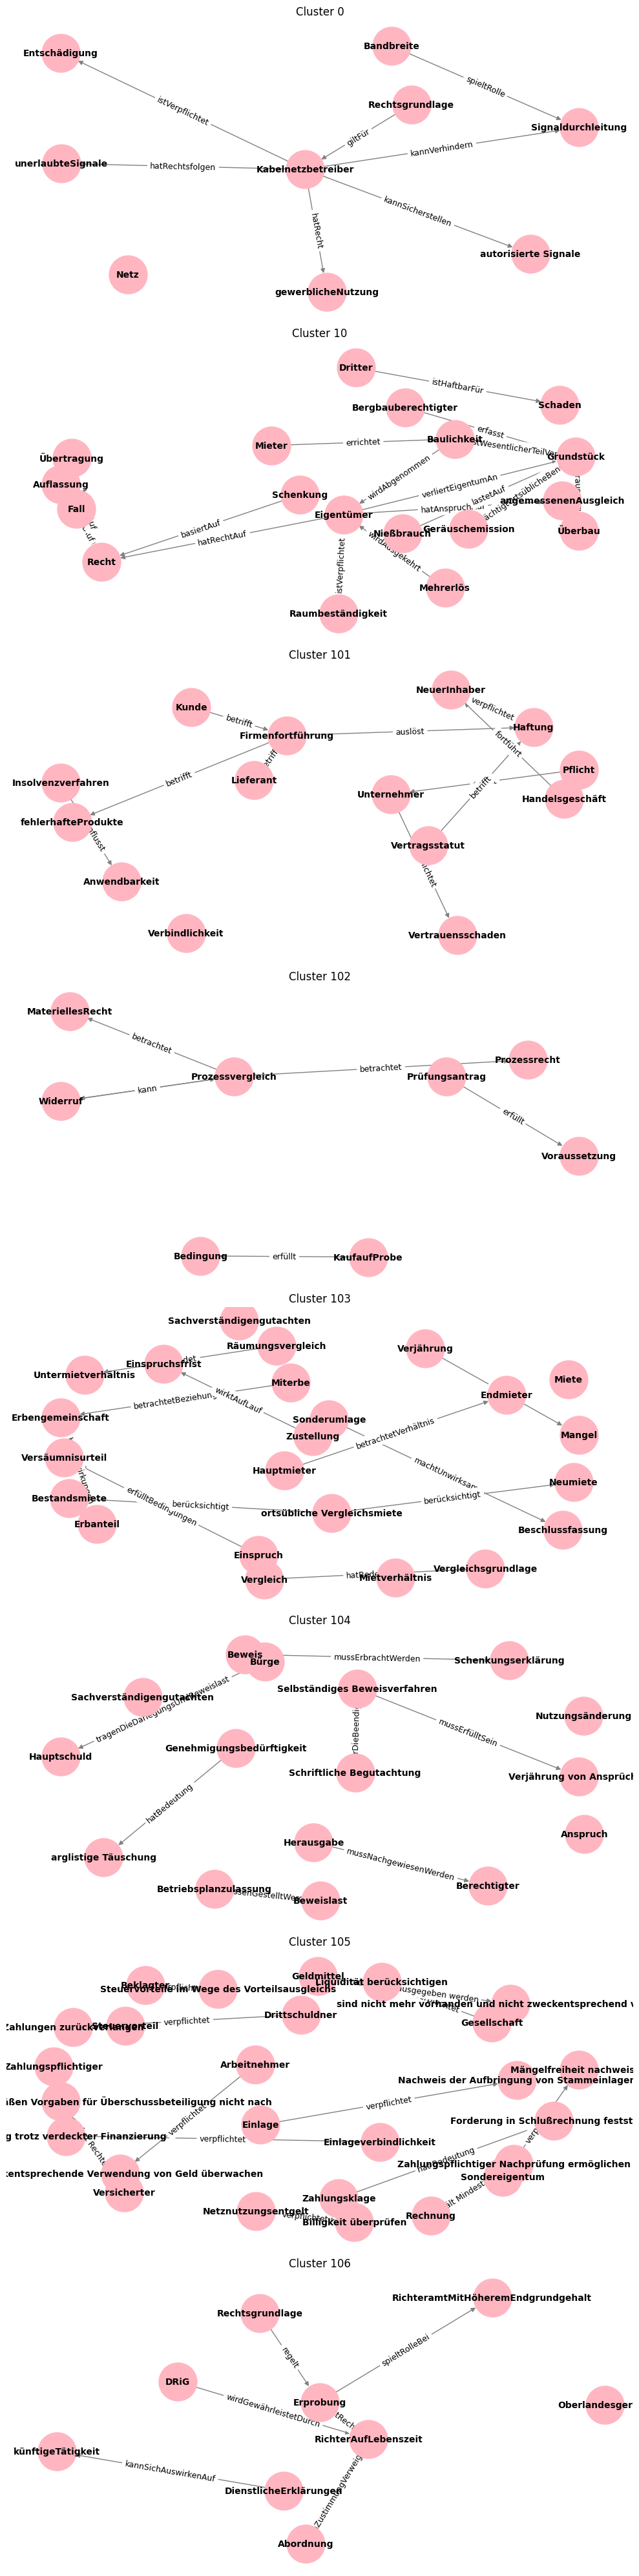

In [20]:
import json
import os
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  # Für die Prüfung der axes-Form

# === Load ontology data ===
ontology_path = "ontology_output/ontology_from_clustered_cqs.json"
with open(ontology_path, "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# === Config ===
num_graphs = 8
cols = 1  # 👉 nur 1 Spalte
rows = num_graphs

fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 5))  # 👉 mehr vertikaler Platz
axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]  # Für Einzelgraph

# === Draw graphs ===
for i, (cluster_id, cluster_data) in enumerate(list(ontology_data.items())[:num_graphs]):
    ontology = cluster_data.get("ontology", {})
    classes = ontology.get("classes", [])
    relationships = ontology.get("relationships", [])

    G = nx.DiGraph()
    G.add_nodes_from(classes)

    for rel in relationships:
        if isinstance(rel, list) and len(rel) == 3:
            subj, pred, obj = rel
            G.add_edge(subj, obj, label=pred)

    pos = nx.spring_layout(G, k=1, seed=42)
    ax = axes[i]
    ax.set_title(f"{cluster_id}", fontsize=12)

    nx.draw(G, pos, with_labels=True, ax=ax,
            node_color="lightpink", node_size=1800,
            font_size=10, font_weight="bold", edge_color="gray")

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, ax=ax)

# === Clean up unused subplots ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Save full figure as PDF ===
plt.tight_layout()
plt.savefig("cluster_ontologien_grossansicht.pdf", bbox_inches="tight")
plt.show()
